# **1st Filter**

/var/folders/g8/gwqmqng10_g3h7m8r02yq1qc0000gn/T/ipykernel_85918/1608634141.py:44: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["시간대그룹"] = df["시간대"].apply(hour_group).astype(float)


X_pca_df shape: (4033906, 28)
C_raw_df shape: (42, 8)
C_pca_df shape: (42, 4)
feature_df shape: (4033906, 30)
unique_feature_df shape: (255975, 30)
H shape: (130021, 30)
J shape: (125954, 30)


100%|██████████| 7/7 [00:31<00:00,  4.49s/it]


nn_df shape: (2600420, 14)
              x_sim        x_dist         c_sim  c_sim_scaled          rank  \
count  2.600420e+06  2.600420e+06  2.600420e+06  2.600420e+06  2.600420e+06   
mean   9.573756e-01  4.262436e-02  5.967011e-01  7.983505e-01  1.050000e+01   
std    4.099809e-02  4.099809e-02  6.720349e-01  3.360175e-01  5.766282e+00   
min    6.972228e-01  0.000000e+00 -9.999492e-01  2.540114e-05  1.000000e+00   
25%    9.460422e-01  1.664798e-02  3.779255e-01  6.889627e-01  5.750000e+00   
50%    9.703138e-01  2.968621e-02  1.000000e+00  1.000000e+00  1.050000e+01   
75%    9.833520e-01  5.395777e-02  1.000000e+00  1.000000e+00  1.525000e+01   
max    1.000000e+00  3.027772e-01  1.000000e+00  1.000000e+00  2.000000e+01   

          time_diff  time_group_diff  
count  2.600420e+06     2.600420e+06  
mean   1.982287e+00     4.955615e-01  
std    1.998465e+00     6.410867e-01  
min    0.000000e+00     0.000000e+00  
25%    1.000000e+00     0.000000e+00  
50%    1.000000e+00     0.0

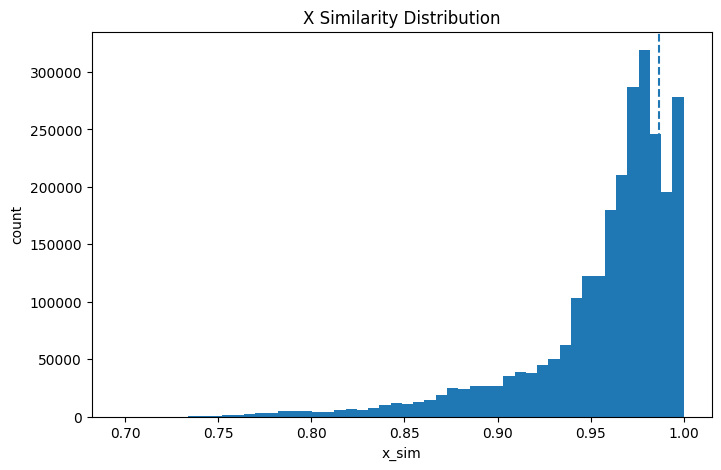

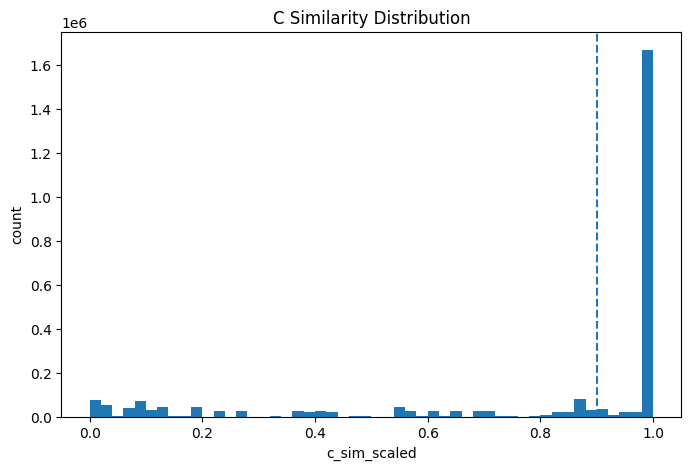

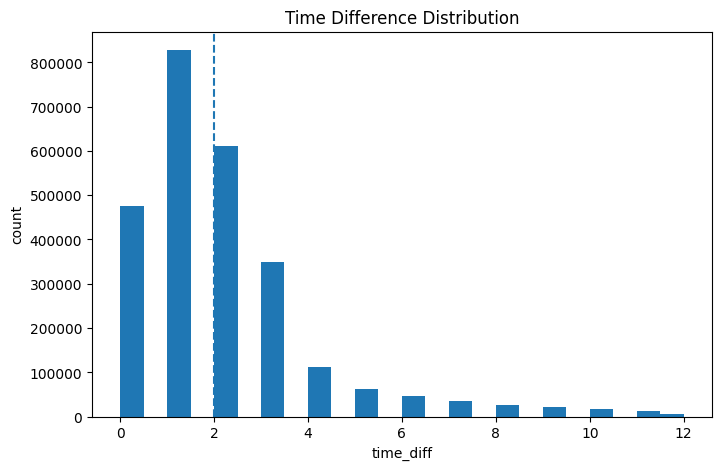

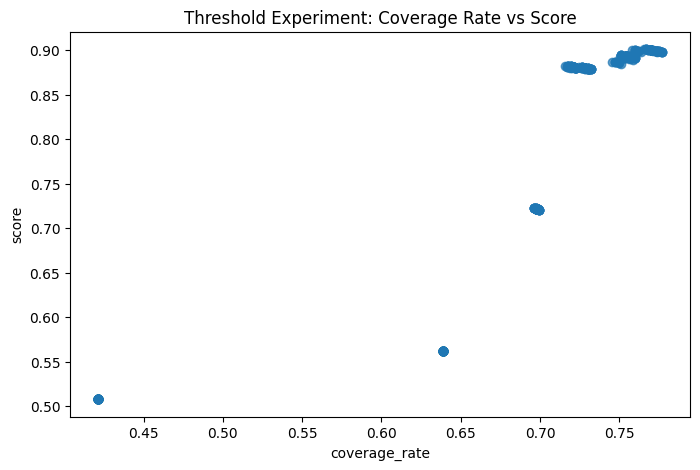

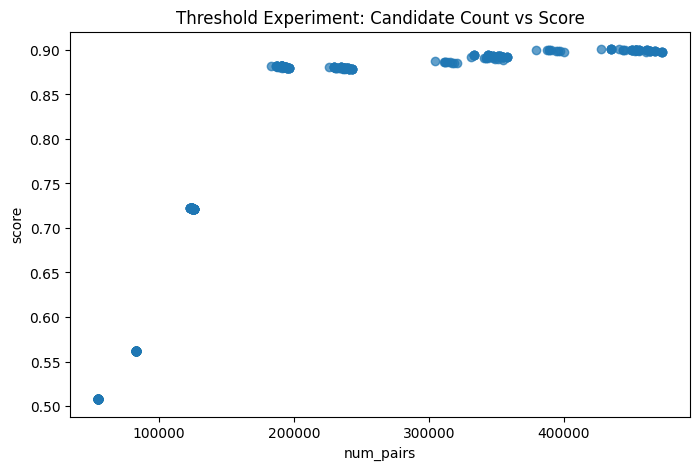

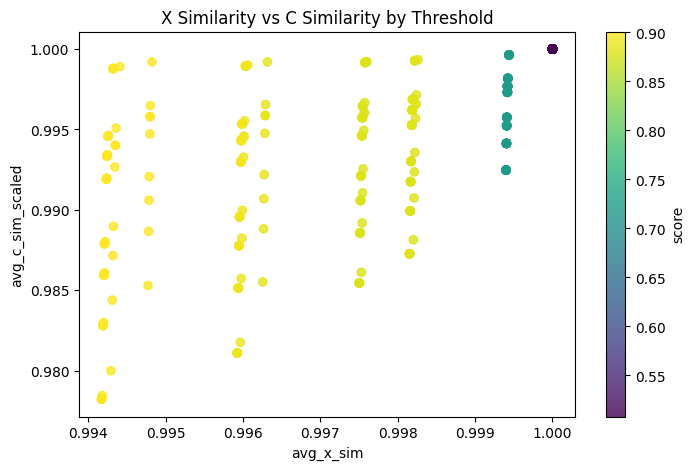

                       stage    count
0               all_nn_pairs  2600420
1  best_threshold_candidates   427348
2        unique_j_candidates   106693


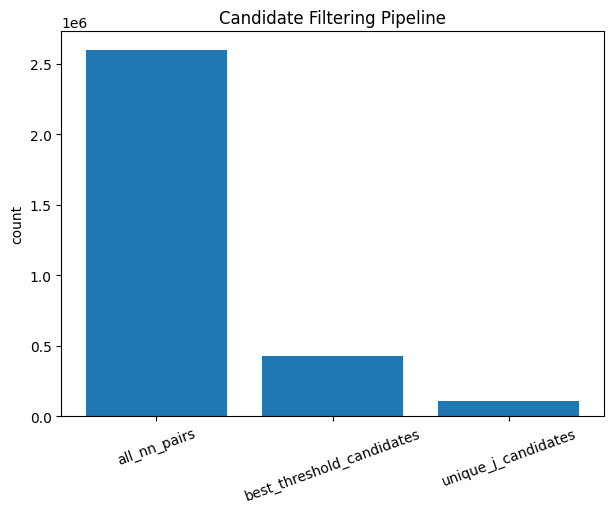

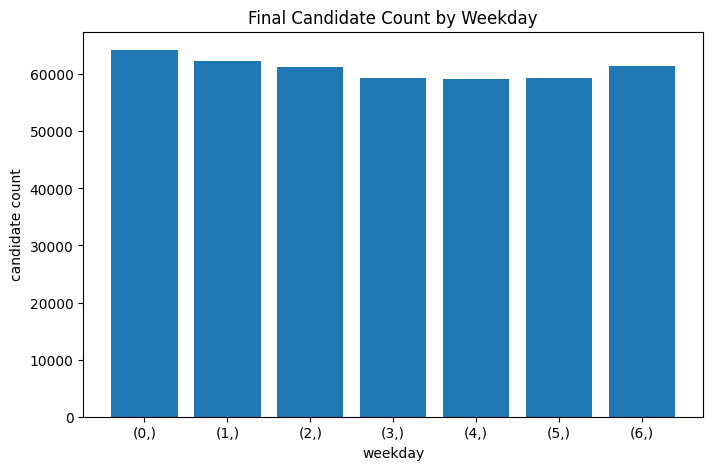

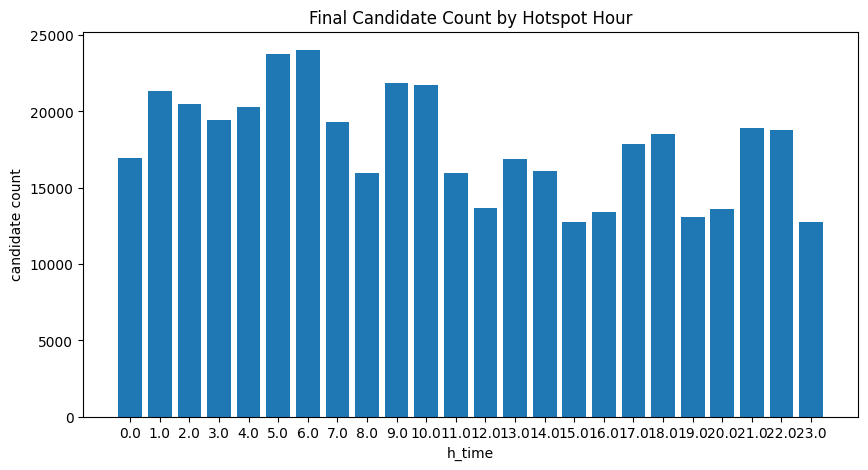

          X_PC1     X_PC2     X_PC3     X_PC4     X_PC5     X_PC6     X_PC7  \
94113 -1.608966  2.943183  4.385765 -0.837174  0.951748  1.896763 -0.733156   
94133 -1.617306  2.938426  4.380174 -0.854759  0.942233  1.962848  0.451052   
93257 -1.643652  2.904708  4.358162 -0.979395  1.078422  0.023318  0.495298   
93376 -1.643849  2.904509  4.358366 -0.975436  1.081241  0.131911  0.343885   
92506 -1.583047  2.960743  4.416561 -0.813926  0.987387  1.007601 -1.114923   
94112 -1.589077  2.956347  4.409010 -0.815043  0.981213  1.389992 -1.324020   
94134 -1.616486  2.939292  4.383271 -0.855770  0.946219  1.922011  0.789753   
94114 -1.616684  2.939093  4.383474 -0.851811  0.949037  2.030605  0.638339   
93273 -1.610213  2.926160  4.391453 -0.937551  1.119590 -0.891093 -1.409377   
93256 -1.616044  2.921963  4.383698 -0.942627  1.110598 -0.617296 -1.467061   
93374 -1.616242  2.921764  4.383901 -0.938668  1.113417 -0.508702 -1.618475   
93375 -1.623485  2.916883  4.374864 -0.946211  1.101

In [184]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from tqdm import tqdm

df = pd.read_csv("../DATA/PROCESS/save_dataset3.csv")

TARGET = "target"

urban_function_features = [
    "hour_sin", "hour_cos", "weekday_sin", "weekday_cos", "month_sin", "month_cos",
    "rest_cnt_500m", "rest_weighted_density_k20",
    "shop_cnt_500m_x", "shop_weighted_density_k20_x",
    "shop_type_entropy_500m", "shop_store_type_entropy_500m",
    "tour_food_cnt_500m", "tour_food_weighted_density_k20", "tour_food_ratio_500m",
    "bus_stop_cnt_500m", "subway_cnt_1000m_x",
    "subway_weighted_access_k5_x", "subway_line_entropy_1000m",
    "concert_total", "movie_seat_cnt", "city_designated_total",
    "gu_walk_area",
]

df["요일"] = df["weekday"].astype(int)
df["시간대"] = df["hour"].astype(float)

def hour_group(h):
    h = int(h)
    if 0 <= h <= 3:
        return 1
    elif 4 <= h <= 7:
        return 2
    elif 8 <= h <= 11:
        return 3
    elif 12 <= h <= 15:
        return 4
    elif 16 <= h <= 19:
        return 5
    else:
        return 6

df["시간대그룹"] = df["시간대"].apply(hour_group).astype(float)

X_raw = df[urban_function_features].replace([np.inf, -np.inf], np.nan).fillna(0)

x_scaler = StandardScaler()
X_scaled = x_scaler.fit_transform(X_raw)

x_pca_model = PCA(n_components=0.95, random_state=42)
X_pca = x_pca_model.fit_transform(X_scaled)

x_cols = [f"X_PC{i+1}" for i in range(X_pca.shape[1])]

X_pca_df = pd.DataFrame(X_pca, columns=x_cols)

X_pca_df["original_index"] = df.index.values

meta_cols = [
    "datetime",
    "자치구코드",
    "위도",
    "경도",
    "hour",
    "weekday",
    "month",
]

for col in meta_cols:
    if col in df.columns:
        X_pca_df[col] = df[col].values

X_pca_df["요일"] = df["요일"].values
X_pca_df["시간대"] = df["시간대"].values
X_pca_df["시간대그룹"] = df["시간대그룹"].values
X_pca_df[TARGET] = df[TARGET].astype(int).values

df1 = pd.read_parquet("../DATA/CARD/korean.parquet")
df2 = pd.read_parquet("../DATA/CARD/foreigner.parquet")

DF = pd.concat([df1, df2], ignore_index=True)

weekday_map = {
    "월요일": 0, "화요일": 1, "수요일": 2, "목요일": 3,
    "금요일": 4, "토요일": 5, "일요일": 6,
    "0": 0, "1": 1, "2": 2, "3": 3, "4": 4, "5": 5, "6": 6,
}

DF["요일"] = DF["요일"].astype(str).str.strip().map(weekday_map)

if DF["요일"].isna().any():
    print(DF.loc[DF["요일"].isna(), "요일"].head(20))
    raise ValueError("요일 매핑 실패")

DF["요일"] = DF["요일"].astype(int)
DF["시간대"] = DF["시간대"].astype(float)

amount_col = "total_card_amount"
industry_col = "industry_group"

DF[amount_col] = pd.to_numeric(DF[amount_col], errors="coerce").fillna(0)

card_group = (
    DF.groupby(["요일", "시간대", industry_col], as_index=False)
    .agg(industry_amount=(amount_col, "sum"))
)

total_group = (
    card_group.groupby(["요일", "시간대"], as_index=False)
    .agg(total_amount=("industry_amount", "sum"))
)

card_group = card_group.merge(
    total_group,
    on=["요일", "시간대"],
    how="left"
)

card_group["amount_ratio"] = (
    card_group["industry_amount"] /
    card_group["total_amount"].replace(0, np.nan)
).fillna(0)

C_raw_df = card_group.pivot_table(
    index=["요일", "시간대"],
    columns=industry_col,
    values="amount_ratio",
    fill_value=0
).reset_index()

C_raw_df.columns = [
    str(c) if c in ["요일", "시간대"] else f"amount_ratio_{c}"
    for c in C_raw_df.columns
]

amount_cols = [c for c in C_raw_df.columns if c.startswith("amount_ratio_")]

def entropy_from_cols(row, cols):
    p = row[cols].to_numpy(dtype=float)
    p = p[p > 0]
    if len(p) == 0:
        return 0
    return -np.sum(p * np.log(p))

C_raw_df["amount_industry_entropy"] = C_raw_df.apply(
    lambda r: entropy_from_cols(r, amount_cols),
    axis=1
)

C_raw_df["amount_dominant_ratio"] = C_raw_df[amount_cols].max(axis=1)

c_feature_cols = [
    c for c in C_raw_df.columns
    if c not in ["요일", "시간대"]
]

C_raw = C_raw_df[c_feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

c_scaler = StandardScaler()
C_scaled = c_scaler.fit_transform(C_raw)

c_pca_model = PCA(n_components=0.95, random_state=42)
C_pca = c_pca_model.fit_transform(C_scaled)

c_cols = [f"C_PC{i+1}" for i in range(C_pca.shape[1])]

C_pca_df = pd.DataFrame(C_pca, columns=c_cols)
C_pca_df["요일"] = C_raw_df["요일"].astype(int).values
C_pca_df["시간대그룹"] = C_raw_df["시간대"].astype(float).values

feature_df = X_pca_df.merge(
    C_pca_df,
    on=["요일", "시간대그룹"],
    how="left"
)

feature_df[c_cols] = feature_df[c_cols].fillna(0)

dedup_cols = (
    x_cols
    + c_cols
    + ["요일", "시간대", "시간대그룹", TARGET]
)

unique_feature_df = feature_df.drop_duplicates(
    subset=dedup_cols
).reset_index(drop=True)

H = unique_feature_df[unique_feature_df[TARGET] == 1].copy()
J = unique_feature_df[unique_feature_df[TARGET] == 0].copy()

print("X_pca_df shape:", X_pca_df.shape)
print("C_raw_df shape:", C_raw_df.shape)
print("C_pca_df shape:", C_pca_df.shape)
print("feature_df shape:", feature_df.shape)
print("unique_feature_df shape:", unique_feature_df.shape)
print("H shape:", H.shape)
print("J shape:", J.shape)

k_neighbors = 20
results = []

groups = H.groupby(["요일"])

for weekday, h_group in tqdm(groups, total=groups.ngroups):
    j_group = J[J["요일"] == weekday]

    if len(j_group) == 0:
        continue

    k = min(k_neighbors, len(j_group))

    nn = NearestNeighbors(
        n_neighbors=k,
        metric="cosine"
    )

    nn.fit(j_group[x_cols])

    x_dist, x_idx = nn.kneighbors(h_group[x_cols])
    x_sim = 1 - x_dist

    results.append({
        "요일": weekday,
        "x_dist": x_dist,
        "x_sim": x_sim,
        "x_idx": x_idx,
        "h_index": h_group.index.values,
        "j_index": j_group.index.values
    })

rows = []

for r in results:
    h_indices = r["h_index"]
    j_indices = r["j_index"]

    for i in range(len(h_indices)):
        for rank in range(r["x_sim"].shape[1]):
            rows.append({
                "h_index": h_indices[i],
                "j_index": j_indices[r["x_idx"][i, rank]],
                "rank": rank + 1,
                "x_sim": r["x_sim"][i, rank],
                "x_dist": r["x_dist"][i, rank],
                "요일": r["요일"],
            })

nn_df = pd.DataFrame(rows)

nn_df["h_time"] = unique_feature_df.loc[nn_df["h_index"], "시간대"].values
nn_df["j_time"] = unique_feature_df.loc[nn_df["j_index"], "시간대"].values
nn_df["h_time_group"] = unique_feature_df.loc[nn_df["h_index"], "시간대그룹"].values
nn_df["j_time_group"] = unique_feature_df.loc[nn_df["j_index"], "시간대그룹"].values

raw_time_diff = (nn_df["h_time"] - nn_df["j_time"]).abs()
nn_df["time_diff"] = np.minimum(raw_time_diff, 24 - raw_time_diff)

raw_group_diff = (nn_df["h_time_group"] - nn_df["j_time_group"]).abs()
nn_df["time_group_diff"] = np.minimum(raw_group_diff, 6 - raw_group_diff)

H_c = unique_feature_df.loc[nn_df["h_index"], c_cols].to_numpy()
J_c = unique_feature_df.loc[nn_df["j_index"], c_cols].to_numpy()

num = np.sum(H_c * J_c, axis=1)
den = np.linalg.norm(H_c, axis=1) * np.linalg.norm(J_c, axis=1)

nn_df["c_sim"] = num / np.where(den == 0, 1e-9, den)
nn_df["c_sim_scaled"] = (nn_df["c_sim"] + 1) / 2

print("nn_df shape:", nn_df.shape)
print(nn_df[["x_sim", "x_dist", "c_sim", "c_sim_scaled", "rank", "time_diff", "time_group_diff"]].describe())

x_quantile_list = [0.80, 0.85, 0.90, 0.92, 0.95, 0.97, 0.99]
c_threshold_list = [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]
time_diff_list = [1, 2, 3, 4, 6, 12, 24]

total_h = nn_df["h_index"].nunique()
total_pairs = len(nn_df)

experiment_rows = []

for x_q in x_quantile_list:
    tau_x = nn_df["x_sim"].quantile(x_q)

    for tau_c in c_threshold_list:
        for max_time_diff in time_diff_list:
            temp = nn_df[
                (nn_df["x_sim"] >= tau_x) &
                (nn_df["c_sim_scaled"] >= tau_c) &
                (nn_df["time_diff"] <= max_time_diff)
            ].copy()

            if len(temp) == 0:
                continue

            num_pairs = len(temp)
            num_h_covered = temp["h_index"].nunique()
            coverage_rate = num_h_covered / total_h
            pair_retention_rate = num_pairs / total_pairs
            avg_x_sim = temp["x_sim"].mean()
            avg_c_sim_scaled = temp["c_sim_scaled"].mean()
            avg_rank = temp["rank"].mean()
            c_positive_rate = (temp["c_sim"] > 0).mean()
            rank_diversity = temp["rank"].nunique() / k_neighbors
            avg_time_diff = temp["time_diff"].mean()

            collapse_penalty = 0

            if avg_x_sim > 0.999:
                collapse_penalty += 0.15

            if rank_diversity < 0.20:
                collapse_penalty += 0.15

            if c_positive_rate < 0.30:
                collapse_penalty += 0.15

            if coverage_rate < 0.05:
                collapse_penalty += 0.15

            if avg_time_diff > 6:
                collapse_penalty += 0.10

            score = (
                0.30 * avg_x_sim +
                0.25 * avg_c_sim_scaled +
                0.25 * coverage_rate +
                0.10 * c_positive_rate +
                0.05 * rank_diversity +
                0.05 * (1 / avg_rank)
                - collapse_penalty
            )

            experiment_rows.append({
                "x_quantile": x_q,
                "tau_x": tau_x,
                "tau_c": tau_c,
                "max_time_diff": max_time_diff,
                "num_pairs": num_pairs,
                "num_h_covered": num_h_covered,
                "coverage_rate": coverage_rate,
                "pair_retention_rate": pair_retention_rate,
                "avg_x_sim": avg_x_sim,
                "avg_c_sim_scaled": avg_c_sim_scaled,
                "avg_rank": avg_rank,
                "c_positive_rate": c_positive_rate,
                "rank_diversity": rank_diversity,
                "avg_time_diff": avg_time_diff,
                "collapse_penalty": collapse_penalty,
                "score": score
            })

threshold_exp_df = pd.DataFrame(experiment_rows).sort_values(
    "score",
    ascending=False
).reset_index(drop=True)

best = threshold_exp_df.iloc[0]

best_tau_x = best["tau_x"]
best_tau_c = best["tau_c"]
best_max_time_diff = best["max_time_diff"]

best_candidate_df = nn_df[
    (nn_df["x_sim"] >= best_tau_x) &
    (nn_df["c_sim_scaled"] >= best_tau_c) &
    (nn_df["time_diff"] <= best_max_time_diff)
].copy()

print("best_x_quantile:", best["x_quantile"])
print("best_tau_x:", best_tau_x)
print("best_tau_c:", best_tau_c)
print("best_max_time_diff:", best_max_time_diff)
print("best_score:", best["score"])
print("best_candidate_df shape:", best_candidate_df.shape)

print(threshold_exp_df.head(20))
print(best_candidate_df[["x_sim", "x_dist", "c_sim", "c_sim_scaled", "rank", "time_diff"]].describe())

j_score_df = (
    best_candidate_df
    .groupby("j_index")
    .agg(
        covered_h_count=("h_index", "nunique"),
        pair_count=("h_index", "count"),
        avg_x_sim=("x_sim", "mean"),
        avg_c_sim_scaled=("c_sim_scaled", "mean"),
        avg_rank=("rank", "mean"),
        avg_time_diff=("time_diff", "mean")
    )
    .reset_index()
)

j_candidate_idx = best_candidate_df["j_index"].unique()

candidate_j_df = unique_feature_df.loc[j_candidate_idx].copy()

candidate_j_df = candidate_j_df.merge(
    j_score_df,
    left_index=True,
    right_on="j_index",
    how="left"
)

print("candidate_j_df shape:", candidate_j_df.shape)
print(candidate_j_df.columns)
print(candidate_j_df.head())

plt.figure(figsize=(8, 5))
plt.hist(nn_df["x_sim"], bins=50)
plt.axvline(best_tau_x, linestyle="--")
plt.title("X Similarity Distribution")
plt.xlabel("x_sim")
plt.ylabel("count")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(nn_df["c_sim_scaled"], bins=50)
plt.axvline(best_tau_c, linestyle="--")
plt.title("C Similarity Distribution")
plt.xlabel("c_sim_scaled")
plt.ylabel("count")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(nn_df["time_diff"], bins=24)
plt.axvline(best_max_time_diff, linestyle="--")
plt.title("Time Difference Distribution")
plt.xlabel("time_diff")
plt.ylabel("count")
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(
    threshold_exp_df["coverage_rate"],
    threshold_exp_df["score"],
    alpha=0.7
)
plt.title("Threshold Experiment: Coverage Rate vs Score")
plt.xlabel("coverage_rate")
plt.ylabel("score")
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(
    threshold_exp_df["num_pairs"],
    threshold_exp_df["score"],
    alpha=0.7
)
plt.title("Threshold Experiment: Candidate Count vs Score")
plt.xlabel("num_pairs")
plt.ylabel("score")
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(
    threshold_exp_df["avg_x_sim"],
    threshold_exp_df["avg_c_sim_scaled"],
    c=threshold_exp_df["score"],
    alpha=0.8
)
plt.colorbar(label="score")
plt.title("X Similarity vs C Similarity by Threshold")
plt.xlabel("avg_x_sim")
plt.ylabel("avg_c_sim_scaled")
plt.show()

summary_df = pd.DataFrame({
    "stage": [
        "all_nn_pairs",
        "best_threshold_candidates",
        "unique_j_candidates"
    ],
    "count": [
        len(nn_df),
        len(best_candidate_df),
        len(candidate_j_df)
    ]
})

print(summary_df)

plt.figure(figsize=(7, 5))
plt.bar(summary_df["stage"], summary_df["count"])
plt.title("Candidate Filtering Pipeline")
plt.ylabel("count")
plt.xticks(rotation=20)
plt.show()

weekday_count = best_candidate_df.groupby("요일").size().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(weekday_count.index.astype(str), weekday_count.values)
plt.title("Final Candidate Count by Weekday")
plt.xlabel("weekday")
plt.ylabel("candidate count")
plt.show()

hour_count = best_candidate_df.groupby("h_time").size().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(hour_count.index.astype(str), hour_count.values)
plt.title("Final Candidate Count by Hotspot Hour")
plt.xlabel("h_time")
plt.ylabel("candidate count")
plt.show()

top_candidates = candidate_j_df.sort_values(
    ["covered_h_count", "avg_x_sim", "avg_c_sim_scaled"],
    ascending=False
).head(20)

print(top_candidates)

best_candidate_df.to_csv("../DATA/PROCESS/best_candidate_df.csv", index=False)
threshold_exp_df.to_csv("../DATA/PROCESS/threshold_experiment_result.csv", index=False)
candidate_j_df.to_csv("../DATA/PROCESS/candidate_j_df.csv", index=False)

# Context-Aware Hidden Spot Candidate Retrieval

## 1. 목적

본 단계의 목적은 혼잡 지역(`target=1`)과 유사한 특성을 가지지만 혼잡하지 않은 후보 지역(`target=0`)을 탐색하는 것이다.

단순히 가까운 지역을 찾는 것이 아니라, 다음 세 가지 조건을 동시에 고려하였다.

1. 공간·입지·도시 기능이 유사한가?
2. 소비 맥락이 유사한가?
3. 시간대가 현실적으로 비교 가능한 범위 안에 있는가?

따라서 본 과정은 다음과 같은 구조를 가진다.

```text
X feature 기반 공간/도시기능 유사도 탐색
+ C feature 기반 소비 맥락 유사도 검증
+ 주기성을 반영한 시간 차이 제약
+ threshold experiment를 통한 최적 후보군 선정
````

---

## 2. 데이터 구성

### 2.1 X 데이터

X 데이터는 혼잡 여부 예측 및 후보 지역의 도시 기능을 표현하는 데이터이다.

사용한 원본 파일은 다음과 같다.

```python
../DATA/PROCESS/save_dataset3.csv
```

이 데이터는 약 403만 개 행으로 구성되어 있으며, 각 행은 특정 시점과 위치의 관측치를 나타낸다.

주요 기준 컬럼은 다음과 같다.

| 컬럼         | 의미      |
| ---------- | ------- |
| `weekday`  | 요일      |
| `hour`     | 시간대     |
| `target`   | 혼잡 여부   |
| `위도`, `경도` | 위치 정보   |
| `자치구코드`    | 행정구역 정보 |

---

## 3. X feature: 도시 기능 기반 feature

X feature는 지역의 공간적·입지적·도시 기능적 특성을 표현하기 위해 사용하였다.

사용한 feature는 다음과 같다.

### 3.1 Temporal feature

시간 주기성을 반영하기 위해 이미 sine/cosine encoding된 변수를 사용하였다.

| Feature       | 의미                  |
| ------------- | ------------------- |
| `hour_sin`    | 시간의 sine encoding   |
| `hour_cos`    | 시간의 cosine encoding |
| `weekday_sin` | 요일의 sine encoding   |
| `weekday_cos` | 요일의 cosine encoding |
| `month_sin`   | 월의 sine encoding    |
| `month_cos`   | 월의 cosine encoding  |

시간과 요일은 선형적인 값이 아니라 주기적인 값이다.

예를 들어 23시와 0시는 숫자상으로는 23 차이가 나지만, 실제 시간 구조에서는 1시간 차이에 가깝다. 따라서 시간 정보를 단순 정수값으로 넣지 않고 sine/cosine으로 표현하면 이러한 주기성을 보존할 수 있다.

---

### 3.2 Commercial feature

상권 및 점포 밀도를 표현하는 변수이다.

| Feature                        | 의미           |
| ------------------------------ | ------------ |
| `rest_cnt_500m`                | 500m 내 음식점 수 |
| `rest_weighted_density_k20`    | 음식점 가중 밀도    |
| `shop_cnt_500m_x`              | 500m 내 상점 수  |
| `shop_weighted_density_k20_x`  | 상점 가중 밀도     |
| `shop_type_entropy_500m`       | 상점 업종 다양성    |
| `shop_store_type_entropy_500m` | 점포 유형 다양성    |

---

### 3.3 Tourism feature

관광 및 음식 관광 관련 특성을 반영하였다.

| Feature                          | 의미                   |
| -------------------------------- | -------------------- |
| `tour_food_cnt_500m`             | 500m 내 관광 음식 관련 지점 수 |
| `tour_food_weighted_density_k20` | 관광 음식 가중 밀도          |
| `tour_food_ratio_500m`           | 관광 음식 비율             |

---

### 3.4 Transport feature

대중교통 접근성을 반영하였다.

| Feature                       | 의미             |
| ----------------------------- | -------------- |
| `bus_stop_cnt_500m`           | 500m 내 버스정류장 수 |
| `subway_cnt_1000m_x`          | 1000m 내 지하철역 수 |
| `subway_weighted_access_k5_x` | 지하철 가중 접근성     |
| `subway_line_entropy_1000m`   | 지하철 노선 다양성     |

---

### 3.5 Culture feature

문화 시설 및 문화 활동 가능성을 반영하였다.

| Feature                 | 의미                |
| ----------------------- | ----------------- |
| `concert_total`         | 공연 관련 시설 또는 이벤트 수 |
| `movie_seat_cnt`        | 영화관 좌석 수          |
| `city_designated_total` | 시 지정 문화 관련 자원 수   |

---

### 3.6 Walkability feature

보행 환경을 반영하였다.

| Feature        | 의미              |
| -------------- | --------------- |
| `gu_walk_area` | 자치구 단위 보행 가능 면적 |

---

## 4. X feature 전처리

X feature는 서로 단위와 스케일이 다르므로 표준화를 수행하였다.

```python
X_raw = df[urban_function_features].replace([np.inf, -np.inf], np.nan).fillna(0)

x_scaler = StandardScaler()
X_scaled = x_scaler.fit_transform(X_raw)
```

결측치와 무한대 값은 0으로 대체하였다.

이후 PCA를 적용하여 정보 손실을 최소화하면서 차원을 축소하였다.

```python
x_pca_model = PCA(n_components=0.95, random_state=42)
X_pca = x_pca_model.fit_transform(X_scaled)
```

`n_components=0.95`는 전체 분산의 95%를 설명하는 최소 개수의 주성분을 유지한다는 의미이다.

즉, 원래의 여러 도시 기능 feature를 다음과 같은 저차원 embedding으로 변환하였다.

```text
X_PC1, X_PC2, ..., X_PCn
```

이 X embedding은 공간·입지·도시 기능의 종합적인 유사도를 계산하는 데 사용된다.

---

## 5. C feature: 소비 맥락 기반 feature

C feature는 카드 소비 데이터를 기반으로 특정 요일과 시간대의 업종 소비 구조를 표현하기 위해 생성하였다.

사용한 데이터는 다음과 같다.

```python
../DATA/CARD/korean.parquet
../DATA/CARD/foreigner.parquet
```

두 데이터는 각각 내국인 소비와 외국인 소비를 나타내며, 이를 하나로 결합하여 사용하였다.

```python
DF = pd.concat([df1, df2], ignore_index=True)
```

카드 데이터는 다음과 같은 구조를 가진다.

| 컬럼                  | 의미                     |
| ------------------- | ---------------------- |
| `요일`                | 요일                     |
| `시간대`               | 6개 시간대 그룹              |
| `industry_group`    | 업종 그룹                  |
| `total_card_amount` | 해당 업종의 카드 소비 금액        |
| `total_sum`         | 해당 요일·시간대 전체 카드 소비 금액  |
| `amount_ratio`      | 전체 소비 중 해당 업종이 차지하는 비율 |

예시는 다음과 같다.

| 요일  | 시간대 | industry_group | amount_ratio |
| --- | --: | -------------- | -----------: |
| 금요일 |   1 | 기타             |       0.6618 |
| 금요일 |   1 | 문화/여가          |       0.0153 |
| 금요일 |   1 | 소매             |       0.1503 |
| 금요일 |   1 | 음식             |       0.1725 |

---

## 6. C feature 생성 방식

C feature는 단순 소비 금액 자체가 아니라 업종별 소비 비율을 사용하였다.

그 이유는 절대 금액은 규모의 영향을 크게 받지만, 비율은 해당 시간대의 소비 구조를 더 잘 표현하기 때문이다.

예를 들어 다음과 같은 비교가 가능하다.

| 시간대 |   음식 |   소매 | 문화/여가 |   기타 |
| --- | ---: | ---: | ----: | ---: |
| A   | 0.50 | 0.20 |  0.10 | 0.20 |
| B   | 0.10 | 0.60 |  0.05 | 0.25 |

A는 음식 중심 소비 구조이고, B는 소매 중심 소비 구조라고 해석할 수 있다.

따라서 C feature는 다음 질문에 답하기 위한 변수이다.

```text
이 시간대의 소비 활동 구조가 유사한가?
```

---

## 7. C feature의 entropy와 dominant ratio

업종별 비율만 사용하는 것에 더해, 소비 구조의 집중도와 다양성을 표현하기 위해 추가 feature를 생성하였다.

### 7.1 Industry entropy

업종 소비 분포의 다양성을 나타낸다.

```text
entropy가 높다 = 여러 업종에 소비가 분산되어 있다
entropy가 낮다 = 특정 업종에 소비가 집중되어 있다
```

수식은 다음과 같다.

```text
H = -Σ p_i log(p_i)
```

여기서 `p_i`는 업종 `i`의 소비 비율이다.

---

### 7.2 Dominant ratio

가장 큰 업종 비율을 의미한다.

```text
dominant_ratio가 높다 = 특정 업종 중심의 소비 구조
dominant_ratio가 낮다 = 소비가 여러 업종에 분산
```

예를 들어 음식 비율이 0.75라면 해당 시간대는 음식 중심 소비 맥락으로 볼 수 있다.

---

## 8. C feature 전처리 및 PCA

C feature 역시 표준화 후 PCA를 적용하였다.

```python
C_raw = C_raw_df[c_feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

c_scaler = StandardScaler()
C_scaled = c_scaler.fit_transform(C_raw)

c_pca_model = PCA(n_components=0.95, random_state=42)
C_pca = c_pca_model.fit_transform(C_scaled)
```

최종적으로 다음과 같은 C embedding을 생성하였다.

```text
C_PC1, C_PC2, ...
```

C embedding은 업종별 소비 분포, 소비 다양성, dominant industry 구조를 압축한 표현이다.

---

## 9. X와 C 병합

X 데이터는 실제 시간대가 0~23시 단위이다.

반면 C 데이터는 1~6의 시간대 그룹으로 구성되어 있다.

따라서 X 데이터의 `hour`를 6개 시간대 그룹으로 변환한 뒤 병합하였다.

```python
def hour_group(h):
    h = int(h)
    if 0 <= h <= 3:
        return 1
    elif 4 <= h <= 7:
        return 2
    elif 8 <= h <= 11:
        return 3
    elif 12 <= h <= 15:
        return 4
    elif 16 <= h <= 19:
        return 5
    else:
        return 6
```

이후 다음 key를 기준으로 병합하였다.

```text
요일 + 시간대그룹
```

즉, 같은 요일과 같은 시간대 그룹에 해당하는 소비 맥락 embedding을 각 X 관측치에 부여하였다.

---

## 10. 후보 탐색 문제 정의

데이터는 target을 기준으로 두 집합으로 나누었다.

```text
H = 혼잡 지역 집합, target = 1
J = 비혼잡 후보 집합, target = 0
```

목표는 각 혼잡 지역 `h ∈ H`에 대해 비혼잡 후보 `j ∈ J` 중 가장 유사한 후보를 찾는 것이다.

---

## 11. 중복 제거

원본 데이터는 약 403만 행이지만, 같은 feature가 반복되는 경우가 많다.

따라서 다음 기준으로 중복을 제거하였다.

```text
X_PC columns + C_PC columns + 요일 + 시간대 + 시간대그룹 + target
```

중복 제거 후 결과는 다음과 같았다.

| 데이터               |       행 수 |
| ----------------- | --------: |
| 원본 feature_df     | 4,033,906 |
| unique_feature_df |   255,975 |
| H                 |   130,021 |
| J                 |   125,954 |

중복 제거는 다음 이유로 필요하다.

1. 동일 feature가 반복되면 nearest neighbor 결과가 자기복제처럼 나올 수 있다.
2. 연산량이 불필요하게 커진다.
3. similarity 분포가 왜곡된다.

---

## 12. Nearest Neighbor 탐색

Nearest Neighbor 탐색은 같은 요일 안에서 수행하였다.

기존에는 같은 요일과 같은 시간대까지 제한했지만, 그렇게 하면 C feature가 항상 동일해져 소비 맥락 유사도가 의미를 잃었다.

따라서 최종 구조에서는 다음과 같이 설정하였다.

```text
X retrieval: 같은 요일 내에서 도시 기능이 유사한 후보 탐색
C scoring: 시간대 그룹별 소비 맥락 유사도 평가
Time constraint: 주기성을 반영한 시간 차이 제한
```

각 혼잡 지역에 대해 가장 가까운 비혼잡 후보 20개를 찾았다.

```python
NearestNeighbors(
    n_neighbors=20,
    metric="cosine"
)
```

사용한 거리 지표는 cosine distance이다.

```text
cosine similarity = 1 - cosine distance
```

따라서 `x_sim`은 1에 가까울수록 도시 기능적으로 더 유사하다는 의미이다.

---

## 13. C similarity 계산

H와 J 각각의 C embedding에 대해 cosine similarity를 계산하였다.

```text
c_sim = cosine_similarity(C_h, C_j)
```

cosine similarity의 범위는 -1에서 1이다.

이를 해석하기 쉽게 0에서 1 사이로 변환하였다.

```text
c_sim_scaled = (c_sim + 1) / 2
```

따라서 다음과 같이 해석할 수 있다.

|      값 | 의미             |
| -----: | -------------- |
| 1에 가까움 | 소비 맥락이 매우 유사   |
| 0.5 근처 | 뚜렷한 유사성이 약함    |
| 0에 가까움 | 소비 맥락이 반대에 가까움 |

---

## 14. 시간 차이의 주기성 반영

시간은 선형 변수가 아니라 주기적 변수이다.

즉 23시와 0시는 숫자상으로는 23 차이가 나지만, 실제로는 1시간 차이에 가깝다.

따라서 단순 차이값을 사용하지 않고 circular distance를 사용하였다.

```text
raw_diff = |h_time - j_time|

time_diff = min(raw_diff, 24 - raw_diff)
```

예시는 다음과 같다.

| h_time | j_time | 단순 차이 | 주기성 반영 차이 |
| -----: | -----: | ----: | --------: |
|     23 |      0 |    23 |         1 |
|     22 |      1 |    21 |         3 |
|     10 |     12 |     2 |         2 |

이렇게 계산하면 자정 근처의 시간대도 올바르게 가까운 시간으로 처리된다.

---

## 15. 전체 NN 결과 분포

Nearest Neighbor 탐색 결과는 다음과 같았다.

| 지표                |    평균 |
| ----------------- | ----: |
| `x_sim`           | 0.957 |
| `c_sim_scaled`    | 0.798 |
| `rank`            |  10.5 |
| `time_diff`       |  1.98 |
| `time_group_diff` |  0.50 |

이는 같은 요일 내에서 탐색했을 때, 후보들이 전반적으로 높은 도시 기능 유사도를 가지며, 시간 차이 역시 평균 약 2시간 수준으로 비교적 작다는 것을 의미한다.

---

## 16. Threshold Experiment

후보를 최종적으로 선별하기 위해 threshold experiment를 수행하였다.

실험한 threshold는 다음과 같다.

### 16.1 X similarity threshold

`x_sim`의 분위수를 기준으로 threshold를 설정하였다.

```python
x_quantile_list = [0.80, 0.85, 0.90, 0.92, 0.95, 0.97, 0.99]
```

예를 들어 `x_quantile=0.80`은 전체 후보 중 상위 20% 수준의 X similarity를 가진 후보를 남긴다는 의미이다.

---

### 16.2 C similarity threshold

소비 맥락 유사도 기준은 다음과 같이 설정하였다.

```python
c_threshold_list = [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]
```

값이 높을수록 소비 맥락이 더 유사한 후보만 통과한다.

---

### 16.3 Time difference threshold

시간 차이 제한은 다음 후보군을 실험하였다.

```python
time_diff_list = [1, 2, 3, 4, 6, 12]
```

여기서 `max_time_diff=2`는 혼잡 시간과 후보 시간의 차이가 최대 2시간 이내인 후보만 허용한다는 의미이다.

---

## 17. Threshold 평가 지표

각 threshold 조합에 대해 다음 지표를 계산하였다.

| 지표                 | 의미                       |
| ------------------ | ------------------------ |
| `num_pairs`        | threshold를 통과한 후보 pair 수 |
| `num_h_covered`    | 적어도 하나의 후보를 가진 혼잡 지점 수   |
| `coverage_rate`    | 전체 혼잡 지점 중 후보를 가진 비율     |
| `avg_x_sim`        | 후보군의 평균 X 유사도            |
| `avg_c_sim_scaled` | 후보군의 평균 C 유사도            |
| `avg_rank`         | 평균 nearest neighbor rank |
| `c_positive_rate`  | C similarity가 양수인 후보 비율  |
| `rank_diversity`   | 다양한 rank의 후보가 살아남았는지     |
| `avg_time_diff`    | 후보군의 평균 시간 차이            |

---

## 18. Threshold score 설계

최적 threshold를 고르기 위해 단순히 유사도만 보지 않았다.

유사도만 높이면 후보가 너무 적어지고, coverage가 낮아질 수 있기 때문이다.

따라서 다음 요소를 함께 고려하였다.

```text
score =
0.30 × avg_x_sim
+ 0.25 × avg_c_sim_scaled
+ 0.25 × coverage_rate
+ 0.10 × c_positive_rate
+ 0.05 × rank_diversity
+ 0.05 × (1 / avg_rank)
- collapse_penalty
```

각 항목의 의미는 다음과 같다.

| 항목                 | 의미                     |
| ------------------ | ---------------------- |
| `avg_x_sim`        | 도시 기능 유사도              |
| `avg_c_sim_scaled` | 소비 맥락 유사도              |
| `coverage_rate`    | 얼마나 많은 혼잡 지점을 커버하는지    |
| `c_positive_rate`  | 소비 맥락이 반대가 아닌 후보 비율    |
| `rank_diversity`   | 특정 rank에만 후보가 몰리지 않는지  |
| `1 / avg_rank`     | 더 가까운 이웃을 선호           |
| `collapse_penalty` | 지나치게 단순한 해로 붕괴되는 경우 감점 |

---

## 19. Collapse penalty

Threshold 최적화 과정에서 단순히 `x_sim=1`인 후보만 선택하는 현상을 방지하기 위해 penalty를 추가하였다.

예를 들어 다음 경우에는 감점을 부여하였다.

| 조건                       | 의미                     |
| ------------------------ | ---------------------- |
| `avg_x_sim > 0.999`      | 완전히 동일한 후보에만 치우친 경우    |
| `rank_diversity < 0.20`  | 특정 rank 후보만 남은 경우      |
| `c_positive_rate < 0.30` | 소비 맥락이 맞는 후보가 너무 적은 경우 |
| `coverage_rate < 0.05`   | 커버리지가 너무 낮은 경우         |
| `avg_time_diff > 6`      | 시간 차이가 지나치게 큰 경우       |

이 penalty는 threshold가 지나치게 극단적인 방향으로 선택되는 것을 방지하기 위한 장치이다.

---

## 20. 최적 threshold 결과

주기성을 반영한 시간 차이 기준을 적용한 결과, 최적 threshold는 다음과 같이 도출되었다.

| 항목              |      값 |
| --------------- | -----: |
| `x_quantile`    |   0.80 |
| `tau_x`         | 0.9867 |
| `tau_c`         |   0.90 |
| `max_time_diff` |      2 |
| `best_score`    | 0.9008 |

---

## 21. 최종 후보 결과

최적 threshold를 적용한 최종 후보군은 다음과 같다.

| 지표                     |       값 |
| ---------------------- | ------: |
| 최종 후보 pair 수           | 427,348 |
| coverage rate          |   0.765 |
| 평균 X similarity        |   0.994 |
| 평균 C similarity scaled |   0.999 |
| 평균 rank                |    4.36 |
| 평균 time_diff           |    0.74 |
| 최대 time_diff           |       2 |

이는 최종 후보군이 다음 조건을 만족함을 의미한다.

```text
1. 도시 기능적으로 매우 유사하다.
2. 소비 맥락이 거의 동일하다.
3. 시간 차이가 평균 1시간 미만이며, 최대 2시간 이내이다.
4. 전체 혼잡 지점의 약 76.5%를 커버한다.
```

---

## 22. 최종 해석

본 후보 탐색 과정은 단순히 위치가 가까운 지역을 찾는 방식이 아니다.

대신 다음 세 가지 유사성을 함께 고려하였다.

```text
Urban Function Similarity
+ Consumption Context Similarity
+ Cyclic Temporal Consistency
```

즉, 최종 후보는 다음과 같이 해석할 수 있다.

```text
혼잡 지역과 도시 기능이 유사하면서,
동일한 요일의 소비 맥락도 유사하고,
시간적으로도 비교 가능한 비혼잡 대체 후보지
```

이 구조는 단순한 hotspot 탐지를 넘어, 혼잡 지역을 대체할 수 있는 hidden spot 추천 문제로 확장할 수 있다.

---

## 23. 최종 파이프라인 요약

```text
1. 원본 도시 feature 로드
2. 시간·상권·관광·교통·문화·보행 feature 선택
3. StandardScaler로 표준화
4. PCA로 X embedding 생성
5. 카드 데이터에서 업종별 소비 비율 생성
6. entropy, dominant ratio 추가
7. PCA로 C embedding 생성
8. X와 C를 요일·시간대그룹 기준으로 병합
9. target 기준 H/J 분리
10. 같은 요일 내에서 X 기반 Nearest Neighbor 탐색
11. C cosine similarity 계산
12. 시간 차이는 circular distance로 계산
13. X/C/time threshold grid search
14. score 기반 최적 threshold 선택
15. 최종 hidden spot candidate pair 도출
```

```
```


| 단계              |    pair 수 |
| --------------- | --------: |
| 전체 NN pair      | 2,600,420 |
| 최종 threshold 통과 | 약 427,348 |

약 16.4%

# **2nd Filter**

In [185]:
local = pd.read_csv("../DATA/LOCAL/local.csv")

count    106693.000000
mean       2332.895699
std        1593.036952
min          88.805673
25%        1155.061784
50%        1961.397059
75%        3009.051436
max        6807.936102
Name: nearest_local_dist_m, dtype: float64
0.01      88.805673
0.05     374.206358
0.10     682.179831
0.25    1155.061784
0.50    1961.397059
0.75    3009.051436
0.90    4979.281305
0.95    5645.519091
0.99    6807.936102
Name: nearest_local_dist_m, dtype: float64


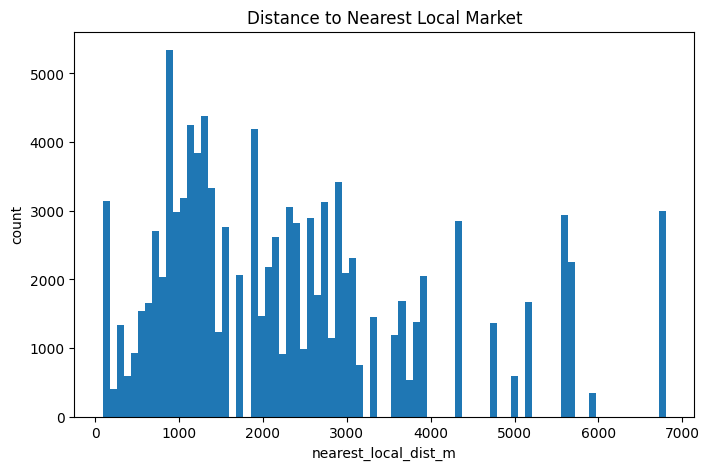

In [186]:
from sklearn.neighbors import BallTree
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

candidate_j_df = candidate_j_df.copy()
local = local.copy()

candidate_j_df["위도"] = pd.to_numeric(candidate_j_df["위도"], errors="coerce")
candidate_j_df["경도"] = pd.to_numeric(candidate_j_df["경도"], errors="coerce")

local["위도"] = pd.to_numeric(local["위도"], errors="coerce")
local["경도"] = pd.to_numeric(local["경도"], errors="coerce")

candidate_j_df = candidate_j_df.dropna(subset=["위도", "경도"]).copy()
local = local.dropna(subset=["위도", "경도"]).copy()

candidate_rad = np.radians(candidate_j_df[["위도", "경도"]].values)
local_rad = np.radians(local[["위도", "경도"]].values)

tree = BallTree(local_rad, metric="haversine")
dist, idx = tree.query(candidate_rad, k=1)

earth_radius_m = 6371000

candidate_j_df["nearest_local_dist_m"] = dist[:, 0] * earth_radius_m
candidate_j_df["nearest_local_idx"] = idx[:, 0]

nearest_local = local.iloc[idx[:, 0]].reset_index(drop=True)

local_cols = [
    "기수", "선정연도", "자치구", "상권명", "대표 주소/위치",
    "매칭_상권_구분", "매칭_상권_코드", "매칭_상권명",
    "서울시_X좌표", "서울시_Y좌표", "매칭_행정동"
]

for col in local_cols:
    if col in nearest_local.columns:
        candidate_j_df[f"nearest_local_{col}"] = nearest_local[col].values

print(candidate_j_df["nearest_local_dist_m"].describe())

print(
    candidate_j_df["nearest_local_dist_m"].quantile(
        [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

plt.figure(figsize=(8, 5))
plt.hist(candidate_j_df["nearest_local_dist_m"], bins=80)
plt.title("Distance to Nearest Local Market")
plt.xlabel("nearest_local_dist_m")
plt.ylabel("count")
plt.show()

In [187]:
distance_threshold_list = (
    candidate_j_df["nearest_local_dist_m"]
    .quantile([0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50])
    .round()
    .astype(int)
    .unique()
    .tolist()
)

distance_threshold_list = sorted(distance_threshold_list)

distance_exp_rows = []

total_candidates = len(candidate_j_df)
total_covered_h = candidate_j_df["covered_h_count"].sum()

for d in distance_threshold_list:
    temp = candidate_j_df[
        candidate_j_df["nearest_local_dist_m"] <= d
    ].copy()

    if len(temp) == 0:
        continue

    candidate_count = len(temp)
    candidate_rate = candidate_count / total_candidates

    covered_h_sum = temp["covered_h_count"].sum()
    covered_h_rate = covered_h_sum / total_covered_h

    avg_dist = temp["nearest_local_dist_m"].mean()
    median_dist = temp["nearest_local_dist_m"].median()

    avg_x_sim = temp["avg_x_sim"].mean()
    avg_c_sim = temp["avg_c_sim_scaled"].mean()
    avg_rank = temp["avg_rank"].mean()

    unique_local_count = temp["nearest_local_상권명"].nunique() if "nearest_local_상권명" in temp.columns else temp["nearest_local_idx"].nunique()
    local_diversity_rate = unique_local_count / local["상권명"].nunique() if "상권명" in local.columns else unique_local_count / len(local)

    distance_score = 1 - (avg_dist / candidate_j_df["nearest_local_dist_m"].max())

    score = (
        0.30 * covered_h_rate +
        0.25 * distance_score +
        0.20 * avg_x_sim +
        0.15 * avg_c_sim +
        0.10 * local_diversity_rate
    )

    distance_exp_rows.append({
        "distance_threshold_m": d,
        "candidate_count": candidate_count,
        "candidate_rate": candidate_rate,
        "covered_h_sum": covered_h_sum,
        "covered_h_rate": covered_h_rate,
        "avg_dist": avg_dist,
        "median_dist": median_dist,
        "avg_x_sim": avg_x_sim,
        "avg_c_sim_scaled": avg_c_sim,
        "avg_rank": avg_rank,
        "unique_local_count": unique_local_count,
        "local_diversity_rate": local_diversity_rate,
        "distance_score": distance_score,
        "score": score
    })

distance_exp_df = pd.DataFrame(distance_exp_rows).sort_values(
    "score",
    ascending=False
).reset_index(drop=True)

distance_exp_df

,distance_threshold_m,candidate_count,candidate_rate,covered_h_sum,covered_h_rate,avg_dist,median_dist,avg_x_sim,avg_c_sim_scaled,avg_rank,unique_local_count,local_diversity_rate,distance_score,score
0,1961,51880,0.486255,257300,0.602085,1073.381683,1155.061784,0.994994,0.999130,3.604898,12,0.705882,0.842334,0.810666
1,1452,42863,0.401741,229612,0.537295,928.307375,1000.103051,0.994761,0.999140,3.890888,11,0.647059,0.863643,0.790628
2,1202,31798,0.298033,181254,0.424137,785.225132,865.296767,0.994929,0.999166,3.986785,10,0.588235,0.884660,0.756090
3,1155,25833,0.242125,143817,0.336534,695.711995,788.525877,0.995151,0.999137,3.757354,10,0.588235,0.897809,0.733137
4,1000,21170,0.198420,92552,0.216573,617.479505,682.179831,0.995616,0.999131,3.035600,9,0.529412,0.909300,0.694231
5,865,15812,0.148201,79281,0.185519,521.493988,528.199998,0.995322,0.999109,3.303988,8,0.470588,0.923399,0.682495
6,682,9596,0.089940,63176,0.147833,356.904742,339.033573,0.994916,0.999012,4.069975,8,0.470588,0.947575,0.677137
7,374,4879,0.045729,32931,0.077059,181.842277,131.087451,0.994870,0.998991,4.036817,4,0.235294,0.973290,0.638792


In [188]:
best_distance_row = distance_exp_df.iloc[0]

best_dist_threshold = best_distance_row["distance_threshold_m"]

print("best_dist_threshold:", best_dist_threshold)
print(best_distance_row)

final_candidate_local_df = candidate_j_df[
    candidate_j_df["nearest_local_dist_m"] <= best_dist_threshold
].copy()

final_candidate_local_df = final_candidate_local_df.sort_values(
    by=[
        "covered_h_count",
        "avg_x_sim",
        "avg_c_sim_scaled",
        "nearest_local_dist_m"
    ],
    ascending=[False, False, False, True]
).copy()

print(final_candidate_local_df.shape)
final_candidate_local_df.head(30)

best_dist_threshold: 1961.0
distance_threshold_m      1961.000000
candidate_count          51880.000000
candidate_rate               0.486255
covered_h_sum           257300.000000
covered_h_rate               0.602085
avg_dist                  1073.381683
median_dist               1155.061784
avg_x_sim                    0.994994
avg_c_sim_scaled             0.999130
avg_rank                     3.604898
unique_local_count          12.000000
local_diversity_rate         0.705882
distance_score               0.842334
score                        0.810666
Name: 0, dtype: float64
(51880, 50)


,X_PC1,X_PC2,X_PC3,X_PC4,X_PC5,X_PC6,X_PC7,X_PC8,X_PC9,X_PC10,...,nearest_local_선정연도,nearest_local_자치구,nearest_local_상권명,nearest_local_대표 주소/위치,nearest_local_매칭_상권_구분,nearest_local_매칭_상권_코드,nearest_local_매칭_상권명,nearest_local_서울시_X좌표,nearest_local_서울시_Y좌표,nearest_local_매칭_행정동
94113,-1.608966,2.943183,4.385765,-0.837174,0.951748,1.896763,-0.733156,1.157044,-0.930270,0.999670,...,2023,종로구,서촌,종로구 통의·체부·필운동 일대,발달상권,3120002,서촌(경복궁역),197511,453304,사직동
94133,-1.617306,2.938426,4.380174,-0.854759,0.942233,1.962848,0.451052,1.710907,-0.076512,0.632846,...,2023,종로구,서촌,종로구 통의·체부·필운동 일대,발달상권,3120002,서촌(경복궁역),197511,453304,사직동
93257,-1.643652,2.904708,4.358162,-0.979395,1.078422,0.023318,0.495298,1.034933,-0.406213,-0.687644,...,2023,종로구,서촌,종로구 통의·체부·필운동 일대,발달상권,3120002,서촌(경복궁역),197511,453304,사직동
93376,-1.643849,2.904509,4.358366,-0.975436,1.081241,0.131911,0.343885,0.353912,-1.355950,-0.402278,...,2023,종로구,서촌,종로구 통의·체부·필운동 일대,발달상권,3120002,서촌(경복궁역),197511,453304,사직동
92506,-1.583047,2.960743,4.416561,-0.813926,0.987387,1.007601,-1.114923,1.516955,1.225430,0.761276,...,2023,종로구,서촌,종로구 통의·체부·필운동 일대,발달상권,3120002,서촌(경복궁역),197511,453304,사직동
94112,-1.589077,2.956347,4.409010,-0.815043,0.981213,1.389992,-1.324020,1.167570,-0.897629,1.072221,...,2023,종로구,서촌,종로구 통의·체부·필운동 일대,발달상권,3120002,서촌(경복궁역),197511,453304,사직동
94134,-1.616486,2.939292,4.383271,-0.855770,0.946219,1.922011,0.789753,1.654199,-0.113359,0.612390,...,2023,종로구,서촌,종로구 통의·체부·필운동 일대,발달상권,3120002,서촌(경복궁역),197511,453304,사직동
94114,-1.616684,2.939093,4.383474,-0.851811,0.949037,2.030605,0.638339,0.973177,-1.063096,0.897755,...,2023,종로구,서촌,종로구 통의·체부·필운동 일대,발달상권,3120002,서촌(경복궁역),197511,453304,사직동
93273,-1.610213,2.926160,4.391453,-0.937551,1.119590,-0.891093,-1.409377,0.897690,0.932576,-0.538758,...,2023,종로구,서촌,종로구 통의·체부·필운동 일대,발달상권,3120002,서촌(경복궁역),197511,453304,사직동
93256,-1.616044,2.921963,4.383698,-0.942627,1.110598,-0.617296,-1.467061,1.229326,-0.240747,-0.513178,...,2023,종로구,서촌,종로구 통의·체부·필운동 일대,발달상권,3120002,서촌(경복궁역),197511,453304,사직동


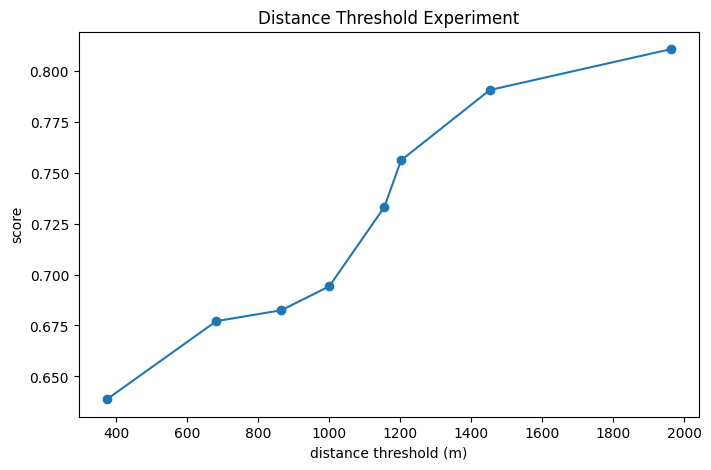

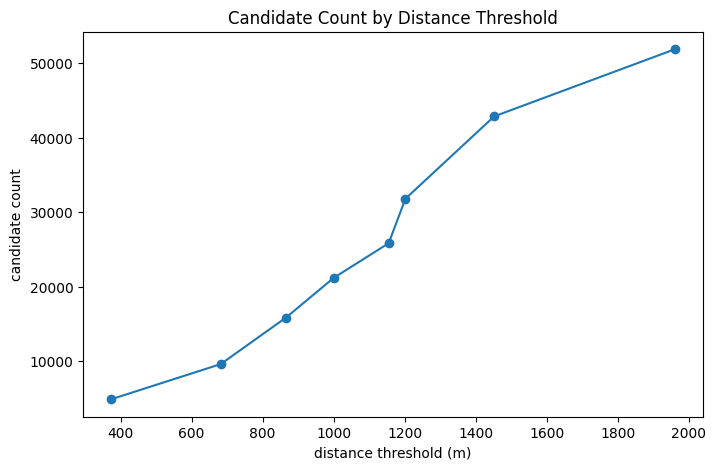

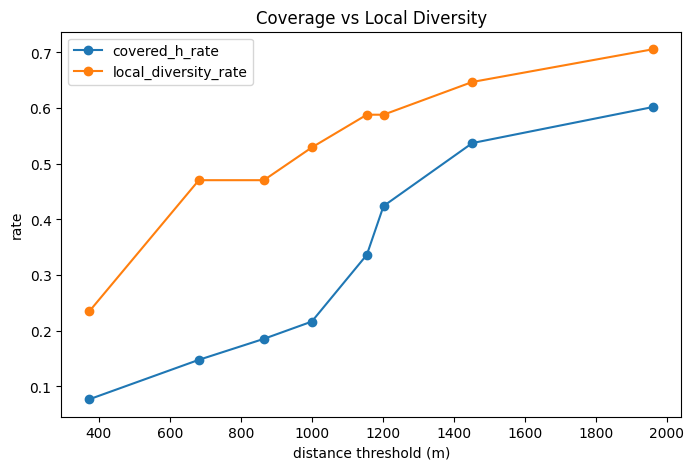

In [189]:
plt.figure(figsize=(8, 5))
plt.plot(
    distance_exp_df["distance_threshold_m"],
    distance_exp_df["score"],
    marker="o"
)
plt.title("Distance Threshold Experiment")
plt.xlabel("distance threshold (m)")
plt.ylabel("score")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(
    distance_exp_df["distance_threshold_m"],
    distance_exp_df["candidate_count"],
    marker="o"
)
plt.title("Candidate Count by Distance Threshold")
plt.xlabel("distance threshold (m)")
plt.ylabel("candidate count")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(
    distance_exp_df["distance_threshold_m"],
    distance_exp_df["covered_h_rate"],
    marker="o",
    label="covered_h_rate"
)
plt.plot(
    distance_exp_df["distance_threshold_m"],
    distance_exp_df["local_diversity_rate"],
    marker="o",
    label="local_diversity_rate"
)
plt.title("Coverage vs Local Diversity")
plt.xlabel("distance threshold (m)")
plt.ylabel("rate")
plt.legend()
plt.show()

In [190]:
distance_exp_df.to_csv(
    "../DATA/PROCESS/distance_threshold_experiment_result.csv",
    index=False
)

final_candidate_local_df.to_csv(
    "../DATA/PROCESS/final_candidate_local_df.csv",
    index=False
)

## 24. 로컬 상권 연계성 기반 2차 필터링

1차 후보군인 `candidate_j_df`는 도시 기능 유사도, 소비 맥락 유사도, 시간 일관성 기준을 통과한 비혼잡 후보지이다. 그러나 이 후보들이 실제 정책적으로 활용 가능한 로컬 상권과 연결되는지는 별도로 검증할 필요가 있다.

따라서 본 단계에서는 각 후보지와 로컬 상권 데이터 `local` 간의 공간적 거리를 계산하고, 로컬 상권과 충분히 가까운 후보지를 선별하였다.

---

## 25. 사용 데이터

### 후보지 데이터

사용한 후보지 데이터는 `candidate_j_df`이다.

주요 컬럼은 다음과 같다.

| 컬럼 | 의미 |
|---|---|
| `위도` | 후보지 위도 |
| `경도` | 후보지 경도 |
| `covered_h_count` | 해당 후보지가 커버하는 혼잡 지점 수 |
| `avg_x_sim` | 평균 도시 기능 유사도 |
| `avg_c_sim_scaled` | 평균 소비 맥락 유사도 |
| `avg_rank` | 평균 nearest neighbor 순위 |
| `avg_time_diff` | 평균 시간 차이 |

### 로컬 상권 데이터

사용한 로컬 상권 데이터는 `local`이다.

주요 컬럼은 다음과 같다.

| 컬럼 | 의미 |
|---|---|
| `기수` | 로컬브랜드 선정 기수 |
| `선정연도` | 선정연도 |
| `자치구` | 자치구 |
| `상권명` | 로컬 상권명 |
| `대표 주소/위치` | 대표 주소 또는 위치 설명 |
| `위도` | 로컬 상권 위도 |
| `경도` | 로컬 상권 경도 |
| `매칭_상권_구분` | 서울시 상권분석서비스 기준 상권 구분 |
| `매칭_상권_코드` | 매칭된 상권 코드 |
| `매칭_상권명` | 매칭된 서울시 상권명 |
| `서울시_X좌표` | 서울시 X좌표 |
| `서울시_Y좌표` | 서울시 Y좌표 |
| `매칭_행정동` | 매칭된 행정동 |

---

## 26. 위도·경도 전처리

거리 계산을 위해 후보지와 로컬 상권의 `위도`, `경도` 컬럼을 숫자형으로 변환하였다.

```python
candidate_j_df["위도"] = pd.to_numeric(candidate_j_df["위도"], errors="coerce")
candidate_j_df["경도"] = pd.to_numeric(candidate_j_df["경도"], errors="coerce")

local["위도"] = pd.to_numeric(local["위도"], errors="coerce")
local["경도"] = pd.to_numeric(local["경도"], errors="coerce")
````

변환 과정에서 결측치가 발생한 행은 거리 계산이 불가능하므로 제거하였다.

```python
candidate_j_df = candidate_j_df.dropna(subset=["위도", "경도"]).copy()
local = local.dropna(subset=["위도", "경도"]).copy()
```

---

## 27. 최근접 로컬 상권 탐색

각 후보지에 대해 가장 가까운 로컬 상권을 찾기 위해 `BallTree`를 사용하였다.

위도·경도는 지구 표면상의 좌표이므로 단순 유클리드 거리가 아니라 `haversine` metric을 사용하였다.

```python
candidate_rad = np.radians(candidate_j_df[["위도", "경도"]].values)
local_rad = np.radians(local[["위도", "경도"]].values)

tree = BallTree(local_rad, metric="haversine")
dist, idx = tree.query(candidate_rad, k=1)
```

`BallTree`는 각 후보지에 대해 가장 가까운 로컬 상권의 index와 거리를 반환한다.

---

## 28. 거리 단위 변환

`haversine` 거리 결과는 라디안 단위로 반환되므로, 지구 반지름을 곱해 meter 단위로 변환하였다.

```python
earth_radius_m = 6371000

candidate_j_df["nearest_local_dist_m"] = dist[:, 0] * earth_radius_m
candidate_j_df["nearest_local_idx"] = idx[:, 0]
```

생성된 주요 컬럼은 다음과 같다.

| 컬럼                     | 의미                        |
| ---------------------- | ------------------------- |
| `nearest_local_dist_m` | 후보지와 가장 가까운 로컬 상권 간 거리(m) |
| `nearest_local_idx`    | 가장 가까운 로컬 상권의 index       |

---

## 29. 최근접 로컬 상권 정보 결합

거리 계산 후, 각 후보지에 가장 가까운 로컬 상권의 정보를 붙였다.

```python
nearest_local = local.iloc[idx[:, 0]].reset_index(drop=True)
```

붙인 로컬 상권 정보는 다음과 같다.

```python
local_cols = [
    "기수", "선정연도", "자치구", "상권명", "대표 주소/위치",
    "매칭_상권_구분", "매칭_상권_코드", "매칭_상권명",
    "서울시_X좌표", "서울시_Y좌표", "매칭_행정동"
]
```

각 컬럼은 `nearest_local_` prefix를 붙여 후보지 데이터에 추가하였다.

예를 들어:

| 생성 컬럼                  | 의미                    |
| ---------------------- | --------------------- |
| `nearest_local_상권명`    | 가장 가까운 로컬 상권명         |
| `nearest_local_자치구`    | 가장 가까운 로컬 상권의 자치구     |
| `nearest_local_매칭_상권명` | 서울시 상권분석서비스 기준 매칭 상권명 |
| `nearest_local_매칭_행정동` | 매칭 행정동                |

---

## 30. 최근접 거리 분포 분석

후보지와 로컬 상권 간 거리 분포는 다음과 같다.

| 통계량   |    거리(m) |
| ----- | -------: |
| count |  106,693 |
| mean  | 2,332.90 |
| std   | 1,593.04 |
| min   |    88.81 |
| 25%   | 1,155.06 |
| 50%   | 1,961.40 |
| 75%   | 3,009.05 |
| max   | 6,807.94 |

분위수 기준으로 보면 다음과 같다.

| 분위수 |    거리(m) |
| --- | -------: |
| 1%  |    88.81 |
| 5%  |   374.21 |
| 10% |   682.18 |
| 25% | 1,155.06 |
| 50% | 1,961.40 |
| 75% | 3,009.05 |
| 90% | 4,979.28 |
| 95% | 5,645.52 |
| 99% | 6,807.94 |

이 결과는 전체 후보지 중 절반이 약 2km 이내의 로컬 상권과 연결되며, 상위 25% 후보지는 약 1.15km 이내에 위치함을 의미한다.

---

## 31. Distance Threshold Experiment

거리 기준을 임의로 500m, 1km 등으로 고정하지 않고, 실제 거리 분포의 분위수를 기반으로 threshold 후보를 구성하였다.

```python
distance_threshold_list = (
    candidate_j_df["nearest_local_dist_m"]
    .quantile([0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50])
    .round()
    .astype(int)
    .unique()
    .tolist()
)
```

즉, 거리 분포를 기준으로 여러 threshold를 실험하고, 각 threshold에서 후보 품질과 커버리지를 평가하였다.

---

## 32. Threshold별 평가 지표

각 거리 threshold `d`에 대해 다음 조건을 만족하는 후보만 남겼다.

```python
candidate_j_df["nearest_local_dist_m"] <= d
```

각 threshold에서 계산한 지표는 다음과 같다.

| 지표                     | 의미                      |
| ---------------------- | ----------------------- |
| `candidate_count`      | threshold 통과 후보 수       |
| `candidate_rate`       | 전체 후보 중 threshold 통과 비율 |
| `covered_h_sum`        | 통과 후보들이 커버하는 혼잡 지점 수의 합 |
| `covered_h_rate`       | 전체 커버 가능 혼잡 지점 대비 커버 비율 |
| `avg_dist`             | 통과 후보의 평균 로컬 상권 거리      |
| `median_dist`          | 통과 후보의 중앙 거리            |
| `avg_x_sim`            | 평균 도시 기능 유사도            |
| `avg_c_sim_scaled`     | 평균 소비 맥락 유사도            |
| `avg_rank`             | 평균 NN rank              |
| `unique_local_count`   | 연결된 고유 로컬 상권 수          |
| `local_diversity_rate` | 전체 로컬 상권 중 연결된 상권 비율    |
| `distance_score`       | 거리가 가까울수록 높아지는 점수       |
| `score`                | 종합 평가 점수                |

---

## 33. Distance Score

거리 자체는 작을수록 좋으므로, 평균 거리를 기반으로 다음 점수를 계산하였다.

```python
distance_score = 1 - (avg_dist / candidate_j_df["nearest_local_dist_m"].max())
```

즉, 평균 거리가 짧을수록 `distance_score`가 높아진다.

---

## 34. 종합 Score 설계

각 threshold의 품질을 비교하기 위해 다음 종합 점수를 사용하였다.

```python
score = (
    0.30 * covered_h_rate +
    0.25 * distance_score +
    0.20 * avg_x_sim +
    0.15 * avg_c_sim +
    0.10 * local_diversity_rate
)
```

각 항목의 의미는 다음과 같다.

| 항목                     |  가중치 | 의미                  |
| ---------------------- | ---: | ------------------- |
| `covered_h_rate`       | 0.30 | 많은 혼잡 지점을 설명할 수 있는가 |
| `distance_score`       | 0.25 | 로컬 상권과 충분히 가까운가     |
| `avg_x_sim`            | 0.20 | 도시 기능 유사성이 높은가      |
| `avg_c_sim`            | 0.15 | 소비 맥락 유사성이 높은가      |
| `local_diversity_rate` | 0.10 | 다양한 로컬 상권과 연결되는가    |

---

## 35. Threshold Experiment 결과

실험 결과는 다음과 같다.

| distance_threshold_m | candidate_count | candidate_rate | covered_h_rate | avg_dist | avg_x_sim | avg_c_sim_scaled | unique_local_count | local_diversity_rate | score |
| -------------------: | --------------: | -------------: | -------------: | -------: | --------: | ---------------: | -----------------: | -------------------: | ----: |
|                 1961 |          51,880 |          0.486 |          0.602 |  1073.38 |   0.99499 |          0.99913 |                 12 |                0.706 | 0.811 |
|                 1452 |          42,863 |          0.402 |          0.537 |   928.31 |   0.99476 |          0.99914 |                 11 |                0.647 | 0.791 |
|                 1202 |          31,798 |          0.298 |          0.424 |   785.23 |   0.99493 |          0.99917 |                 10 |                0.588 | 0.756 |
|                 1155 |          25,833 |          0.242 |          0.337 |   695.71 |   0.99515 |          0.99914 |                 10 |                0.588 | 0.733 |
|                 1000 |          21,170 |          0.198 |          0.217 |   617.48 |   0.99562 |          0.99913 |                  9 |                0.529 | 0.694 |
|                  865 |          15,812 |          0.148 |          0.186 |   521.49 |   0.99532 |          0.99911 |                  8 |                0.471 | 0.682 |
|                  682 |           9,596 |          0.090 |          0.148 |   356.90 |   0.99492 |          0.99901 |                  8 |                0.471 | 0.677 |
|                  374 |           4,879 |          0.046 |          0.077 |   181.84 |   0.99487 |          0.99899 |                  4 |                0.235 | 0.639 |

---

## 36. 최적 Threshold 결과

종합 score 기준으로 가장 높은 threshold는 다음과 같다.

| 항목                     |        값 |
| ---------------------- | -------: |
| `best_dist_threshold`  |    1961m |
| `candidate_count`      |   51,880 |
| `candidate_rate`       |    0.486 |
| `covered_h_rate`       |    0.602 |
| `avg_dist`             | 1073.38m |
| `median_dist`          | 1155.06m |
| `avg_x_sim`            |  0.99499 |
| `avg_c_sim_scaled`     |  0.99913 |
| `avg_rank`             |     3.60 |
| `unique_local_count`   |       12 |
| `local_diversity_rate` |    0.706 |
| `score`                |    0.811 |

---

## 37. 결과 해석

`1961m` threshold는 전체 거리 분포의 중앙값에 해당한다.

이 기준을 적용하면 전체 후보 중 약 48.6%인 51,880개 후보가 남으며, 이 후보들은 전체 커버 가능 혼잡 지점의 약 60.2%를 설명한다.

또한 평균 도시 기능 유사도는 0.995, 평균 소비 맥락 유사도는 0.999로 매우 높게 유지되었다.

즉, `1961m` 기준은 다음 장점을 가진다.

* 후보 수를 충분히 확보한다.
* 혼잡 지점 커버리지가 높다.
* 다양한 로컬 상권과 연결된다.
* X/C 유사도가 거의 손실되지 않는다.

---

## 38. Trade-off 해석

거리 threshold를 키우면 더 많은 후보가 로컬 상권과 연결된 것으로 인정되기 때문에 `candidate_count`, `covered_h_rate`, `local_diversity_rate`는 증가한다. 반대로 threshold를 줄이면 후보 수와 커버리지는 감소하지만, `avg_dist`, `median_dist`가 낮아져 실제 로컬 상권과의 공간적 직접성은 강해진다.

| threshold |   후보 수 | 후보 비율 | covered_h_rate |   평균 거리 |   중앙 거리 | 연결 상권 수 | local_diversity_rate | score |
| --------: | -----: | ----: | -------------: | ------: | ------: | ------: | -------------------: | ----: |
|      374m |  4,879 |  4.6% |           7.7% |  181.8m |  131.1m |       4 |                0.235 | 0.639 |
|      682m |  9,596 |  9.0% |          14.8% |  356.9m |  339.0m |       8 |                0.471 | 0.677 |
|      865m | 15,812 | 14.8% |          18.6% |  521.5m |  528.2m |       8 |                0.471 | 0.682 |
|     1000m | 21,170 | 19.8% |          21.7% |  617.5m |  682.2m |       9 |                0.529 | 0.694 |
|     1155m | 25,833 | 24.2% |          33.7% |  695.7m |  788.5m |      10 |                0.588 | 0.733 |
|     1202m | 31,798 | 29.8% |          42.4% |  785.2m |  865.3m |      10 |                0.588 | 0.756 |
|     1452m | 42,863 | 40.2% |          53.7% |  928.3m | 1000.1m |      11 |                0.647 | 0.791 |
|     1961m | 51,880 | 48.6% |          60.2% | 1073.4m | 1155.1m |      12 |                0.706 | 0.811 |

가장 높은 score는 `1961m`에서 나타났다. 이 기준은 후보 수 51,880개, 후보 비율 48.6%, `covered_h_rate` 60.2%, 연결 로컬 상권 수 12개로 가장 넓은 커버리지와 다양성을 확보한다. 따라서 전체 후보 풀을 최대한 넓게 확보하고, 이후 클러스터링이나 대표 후보 선정 단계에서 다시 압축할 계획이라면 `1961m` 기준이 적합하다.

다만 `1961m`는 평균 거리 1073.4m, 중앙 거리 1155.1m로 로컬 상권과의 실제 공간적 직접성이 다소 약해질 수 있다. 반면 `1000~1200m` 구간은 평균 거리가 약 617.5~785.2m이고 중앙 거리도 약 682.2~865.3m 수준이라, 후보가 실제 로컬 상권 생활권 안에 있을 가능성이 더 높다. 특히 `1202m` 기준은 후보 수 31,798개, `covered_h_rate` 42.4%, 연결 상권 수 10개를 확보하면서도 평균 거리를 785.2m로 유지한다. 즉 커버리지를 일정 수준 확보하면서 공간적 연계성을 더 강하게 보존하는 절충안이다.

따라서 최종 threshold는 목적에 따라 두 가지로 해석할 수 있다.

| 선택 방식        |  threshold | 해석                                             |
| ------------ | ---------: | ---------------------------------------------- |
| Score 최적화 기준 |      1961m | 후보 수, hotspot coverage, 로컬 상권 다양성을 최대한 확보하는 기준 |
| 생활권 보수 기준    | 1000~1200m | 로컬 상권과의 실제 도보 생활권 연계성을 더 강하게 유지하는 기준           |

본 분석에서는 score 기준 최적값은 `1961m`로 확인되었지만, 정책 제안 단계에서 “로컬 상권과 직접적으로 연결 가능한 hidden spot”을 강조하려면 `1000~1200m` 구간을 보수적 기준으로 함께 제시할 수 있다.


---

## 39. 최종 후보 데이터

최종적으로 `best_dist_threshold` 이내 후보를 선별하여 `final_candidate_local_df`를 생성하였다.

```python
final_candidate_local_df = candidate_j_df[
    candidate_j_df["nearest_local_dist_m"] <= best_dist_threshold
].copy()
```

이후 다음 기준으로 정렬하였다.

```python
covered_h_count ↓
avg_x_sim ↓
avg_c_sim_scaled ↓
nearest_local_dist_m ↑
```

즉:

1. 더 많은 혼잡 지점을 커버하고
2. 도시 기능 유사도가 높으며
3. 소비 맥락 유사도가 높고
4. 로컬 상권과 더 가까운 후보

를 우선순위로 두었다.

---

## 40. 최종 의의

본 단계는 1차 유사도 기반 후보군을 정책적으로 활용 가능한 후보군으로 좁히는 과정이다.

단순히 유사한 비혼잡 지역을 찾는 것에서 나아가, 로컬브랜드·골목상권과 실제로 연결 가능한 후보지를 선별함으로써 다음 단계의 분석 기반을 마련하였다.

최종 후보는 다음 조건을 만족한다.

```text
도시 기능 유사성
+ 소비 맥락 유사성
+ 로컬 상권과의 공간적 연계성
```

따라서 `final_candidate_local_df`는 이후 대표 후보지 선정, 클러스터링, 수용여력 분석, 정책적 우선순위 산정의 입력 데이터로 활용할 수 있다.